In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

import optuna
import optuna.visualization as vis
import time

import scipy.stats as st

from sklearn.datasets import  fetch_california_housing
import pandas as pd>
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, make_scorer, mean_absolute_percentage_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

from scipy.stats import ttest_ind
import pickle
from sklearn.pipeline import Pipeline
import joblib

## EDA

In [2]:
df2 = pd.read_csv(r'..\data\raw\listings.csv')

In [3]:
df2.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20250612050654,2025-06-21,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,71615,...,4.60,4.81,4.28,HUTB-002062,t,28,28,0,0,0.33
1,23197,https://www.airbnb.com/rooms/23197,20250612050654,2025-06-23,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,90417,...,4.99,4.65,4.68,HUTB005057,f,1,1,0,0,0.51
2,32711,https://www.airbnb.com/rooms/32711,20250612050654,2025-06-22,city scrape,Sagrada Familia area - Còrsega 1,A lovely two bedroom apartment only 250 m from...,What's nearby <br />This apartment is located...,https://a0.muscache.com/pictures/357b25e4-f414...,135703,...,4.89,4.89,4.47,HUTB-001722,f,3,3,0,0,0.87
3,34241,https://www.airbnb.com/rooms/34241,20250612050654,2025-06-22,city scrape,Stylish Top Floor Apartment - Ramblas Plaza Real,Located in close proximity to Plaza Real and L...,NaN,https://a0.muscache.com/pictures/2437facc-2fe7...,73163,...,4.68,4.73,4.23,Exempt,f,3,3,0,0,0.14
4,347824,https://www.airbnb.com/rooms/347824,20250612050654,2025-06-22,city scrape,"Ideal Happy Location Barceloneta Beach, Old Town!",Please send us a message to confirm availabili...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,1447144,...,3.67,5.00,4.00,HUTB-076700,f,355,355,0,0,0.02


In [4]:
df2.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [5]:
df2['price'].value_counts()

price
$80.00       172
$60.00       158
$100.00      158
$50.00       142
$75.00       141
            ... 
$665.00        1
$890.00        1
$609.00        1
$557.00        1
$2,797.00      1
Name: count, Length: 891, dtype: int64

In [6]:
df2['price'] = df2['price'].replace('[\$,]', '',regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\User\AppData\Local\Temp\ipykernel_12240\1121066955.py:1: SyntaxWarning: invalid escape sequence '\$'
  df2['price'] = df2['price'].replace('[\$,]', '',regex=True).astype(float)


In [7]:
df = df2[['id','neighbourhood_group_cleansed','property_type','room_type','accommodates','bathrooms','bedrooms','price']]

In [8]:
df.head()

,id,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,price
0,18674,Eixample,Entire rental unit,Entire home/apt,8,2.0,3.0,232.0
1,23197,Sant Martí,Entire rental unit,Entire home/apt,5,2.0,3.0,382.0
2,32711,Gràcia,Entire rental unit,Entire home/apt,6,1.5,2.0,186.0
3,34241,Ciutat Vella,Entire condo,Entire home/apt,2,1.0,1.0,131.0
4,347824,Ciutat Vella,Entire rental unit,Entire home/apt,3,1.0,1.0,285.0


In [9]:
df = df[df['property_type'] == 'Entire rental unit']

In [10]:
df.shape

(10416, 8)

In [11]:
df.head()

,id,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,price
0,18674,Eixample,Entire rental unit,Entire home/apt,8,2.0,3.0,232.0
1,23197,Sant Martí,Entire rental unit,Entire home/apt,5,2.0,3.0,382.0
2,32711,Gràcia,Entire rental unit,Entire home/apt,6,1.5,2.0,186.0
4,347824,Ciutat Vella,Entire rental unit,Entire home/apt,3,1.0,1.0,285.0
6,352772,Eixample,Entire rental unit,Entire home/apt,4,1.0,2.0,185.0


In [12]:
df['property_type'].unique()

array(['Entire rental unit'], dtype=object)

In [13]:
df['room_type'].unique()

array(['Entire home/apt'], dtype=object)

In [14]:
df['neighbourhood_group_cleansed'].unique()

array(['Eixample', 'Sant Martí', 'Gràcia', 'Ciutat Vella',
       'Sants-Montjuïc', 'Sarrià-Sant Gervasi', 'Sant Andreu',
       'Les Corts', 'Horta-Guinardó', 'Nou Barris'], dtype=object)

In [15]:
df.duplicated().sum()

0

In [16]:
df.isna().sum()

id                                0
neighbourhood_group_cleansed      0
property_type                     0
room_type                         0
accommodates                      0
bathrooms                       944
bedrooms                         39
price                           944
dtype: int64

In [17]:
dfs_neighs = []

for neighbourhood in df['neighbourhood_group_cleansed'].unique():
    df_neigh = df[df['neighbourhood_group_cleansed'] == neighbourhood].copy()

    # Garantir que price seja numérico
    df_neigh['price'] = (
        df_neigh['price']
        .replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

    df_neigh['bathrooms'] = df_neigh.groupby('bedrooms')['bathrooms'].transform(lambda x: x.fillna(x.mean()))
    df_neigh['price'] = df_neigh.groupby('bedrooms')['price'].transform(lambda x: x.fillna(x.mean()))

    dfs_neighs.append(df_neigh)

df_clean = pd.concat(dfs_neighs, ignore_index=True)

In [18]:
df_clean.isna().sum()

id                               0
neighbourhood_group_cleansed     0
property_type                    0
room_type                        0
accommodates                     0
bathrooms                       41
bedrooms                        39
price                           41
dtype: int64

In [19]:
df_clean =  df_clean.dropna(subset=['price'])

In [20]:
df_clean.shape

(10375, 8)

In [21]:
df_clean.isna().sum()


id                              0
neighbourhood_group_cleansed    0
property_type                   0
room_type                       0
accommodates                    0
bathrooms                       0
bedrooms                        0
price                           0
dtype: int64

In [22]:
df_clean.head()

,id,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,price
0,18674,Eixample,Entire rental unit,Entire home/apt,8,2.0,3.0,232.0
1,352772,Eixample,Entire rental unit,Entire home/apt,4,1.0,2.0,185.0
2,365911,Eixample,Entire rental unit,Entire home/apt,4,1.5,3.0,422.0
3,384063,Eixample,Entire rental unit,Entire home/apt,6,2.0,3.0,286.0
4,384464,Eixample,Entire rental unit,Entire home/apt,2,1.0,1.0,800.0


C:\Users\User\AppData\Local\Temp\ipykernel_12240\1543427780.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airbnb_price_neigh, y='neighbourhood_group_cleansed', x='price', palette='viridis')


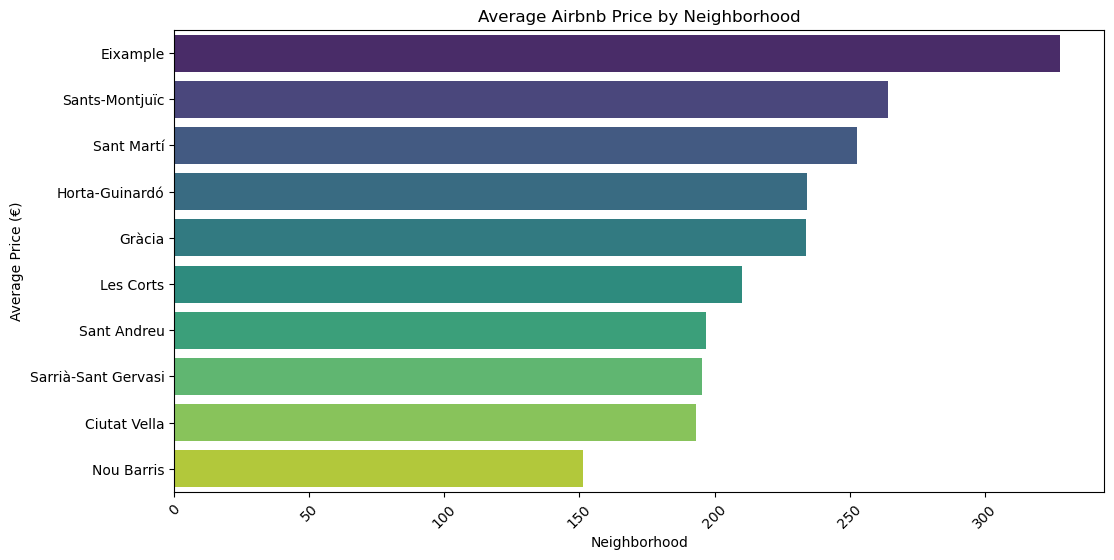

In [25]:
airbnb_price_neigh = df_clean.groupby('neighbourhood_group_cleansed')['price'].mean().reset_index().sort_values(by='price',ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=airbnb_price_neigh, y='neighbourhood_group_cleansed', x='price', palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Airbnb Price by Neighborhood')
plt.ylabel('Average Price (€)')
plt.xlabel('Neighborhood')
#plt.savefig(r"..\figures\price_per_neighb_airbnb.png")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12240\1351409962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airbnb_price_bed, x='bedrooms', y='price', palette='magma')


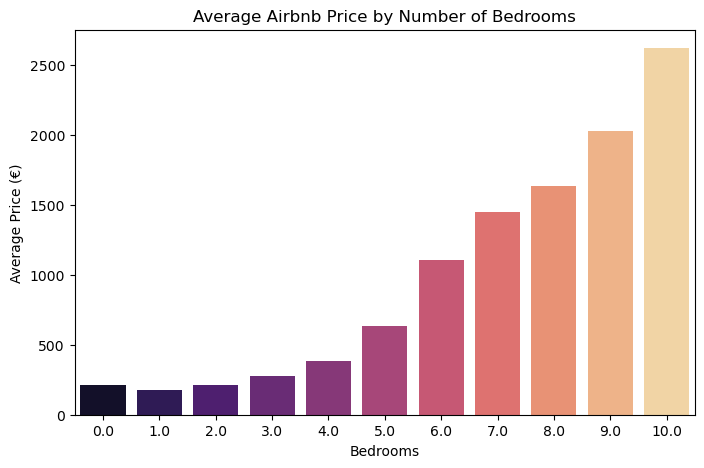

In [24]:
airbnb_price_bed = (df[df['bedrooms']<= 10].groupby('bedrooms')['price'].mean().reset_index())

plt.figure(figsize=(8,5))
sns.barplot(data=airbnb_price_bed, x='bedrooms', y='price', palette='magma')
plt.title('Average Airbnb Price by Number of Bedrooms')
plt.ylabel('Average Price (€)')
plt.xlabel('Bedrooms')
plt.savefig(r"..\figures\price_per_bedrooms_airbnb.png")
plt.show()

In [26]:
## Data for presentation

In [27]:
avg_price_airbnb = df_clean['price'].mean()   

In [28]:
avg_price_airbnb_month = avg_price_airbnb * 30

In [30]:
avg_price_neigh_airbnb = df_clean.groupby('neighbourhood_group_cleansed')['price'].mean().sort_values(ascending=False)

In [39]:
df_clean = df_clean[df_clean['estimated_m2'] > 0]  # remove onde m² é 0
avg_price_per_m2_airbnb = df_clean['price_per_m2_month'].mean()

In [32]:
listings_count_airbnb = df_clean['neighbourhood_group_cleansed'].value_counts(normalize=True) * 100

In [40]:
print(avg_price_airbnb)
print(avg_price_airbnb_month)
print(avg_price_per_m2_airbnb)
print(avg_price_neigh_airbnb)

261.72580560151823
7851.774168045547
147.4622398665264
neighbourhood_group_cleansed
Eixample               327.779450
Sants-Montjuïc         264.299257
Sant Martí             252.634491
Horta-Guinardó         234.331615
Gràcia                 233.850646
Les Corts              210.201454
Sant Andreu            196.748005
Sarrià-Sant Gervasi    195.501258
Ciutat Vella           193.189164
Nou Barris             151.488208
Name: price, dtype: float64


In [41]:
## percentage of offers by neighbouhood

In [42]:
airbnb_counts = df_clean['neighbourhood_group_cleansed'].value_counts()
airbnb_pct = (airbnb_counts / airbnb_counts.sum()) * 100

In [43]:
top6_airbnb = airbnb_pct.head(6)

In [45]:
print(top6_airbnb.round(2))

neighbourhood_group_cleansed
Eixample               38.36
Ciutat Vella           21.32
Sants-Montjuïc         10.06
Sant Martí              9.96
Gràcia                  8.60
Sarrià-Sant Gervasi     5.60
Name: count, dtype: float64
